# Phase 2 — Exploration et nettoyage

Objectifs de cette phase :
1. **Charger** les données brutes (`data/raw/`).
2. **Explorer** la structure et les distributions.
3. **Vérifier la qualité** : valeurs manquantes, doublons, valeurs aberrantes.

On commence par le jeu de données des **monstres** (Open5e), puis on fera de même pour les **personnages joueurs** (dnddata).

> Approche pas-à-pas : chaque section répond à une question précise sur les données.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Options d'affichage : voir toutes les colonnes, largeur confortable.
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")

# Chemin vers les données brutes (le notebook est dans notebooks/).
RAW = Path.cwd().parent / "data" / "raw"
print("Dossier data/raw :", RAW)
print("Fichiers :", [p.name for p in RAW.glob("*.csv")])

Dossier data/raw : /home/codenam/Github/ml-dnd-combat-encounter-difficulty/data/raw
Fichiers : ['characters_all.csv', 'monsters.csv', 'characters_unique.csv']


## 1. Chargement des données

On charge les monstres et les personnages (jeu dédupliqué) et on regarde leurs dimensions.

In [2]:
monsters = pd.read_csv(RAW / "monsters.csv")
characters = pd.read_csv(RAW / "characters_unique.csv")

print("Monstres   :", monsters.shape, "(lignes, colonnes)")
print("Personnages:", characters.shape, "(lignes, colonnes)")

Monstres   : (3207, 23) (lignes, colonnes)
Personnages: (7946, 35) (lignes, colonnes)


## 2. Premier aperçu — Monstres

Avant toute analyse, on regarde à quoi ressemblent les données : les premières lignes,
les types de colonnes, et un résumé statistique des colonnes numériques.

In [3]:
monsters.head()

,slug,name,size,type,subtype,alignment,armor_class,armor_desc,hit_points,hit_dice,strength,dexterity,constitution,intelligence,wisdom,charisma,challenge_rating,cr,document__title,speed,skills,actions,special_abilities
0,a-mi-kuk,A-mi-kuk,Huge,Aberration,NaN,chaotic evil,14,natural armor,115,10d12+50,21,8,20,7,14,10,7,7.0,Tome of Beasts 2,"{""swim"": 40, ""burrow"": 20, ""walk"": 30}","{""athletics"": 10, ""perception"": 5, ""stealth"": 2}","[{""name"": ""Multiattack"", ""desc"": ""The a-mi-kuk...","[{""name"": ""Hold Breath"", ""desc"": ""The a-mi-kuk..."
1,aalpamac,Aalpamac,Huge,Monstrosity,NaN,unaligned,16,natural armor,136,13d12+52,21,10,19,2,16,10,7,7.0,Tome of Beasts 2,"{""walk"": 15, ""swim"": 50}","{""perception"": 6}","[{""name"": ""Multiattack"", ""desc"": ""The aalpamac...","[{""name"": ""Amphibious"", ""desc"": ""The aalpamac ..."
2,aatxe,Aatxe,Large,Celestial,shapechanger,lawful good,14,natural armor,105,10d10+50,22,12,20,10,14,14,5,5.0,Creature Codex,"{""walk"": 50}","{""athletics"": 9, ""intimidation"": 5}","[{""attack_bonus"": 9, ""damage_dice"": ""3d8+6"", ""...","[{""desc"": ""If the aatxe moves at least 20 feet..."
3,abaasy,Abaasy,Huge,Giant,NaN,neutral evil,18,"armor scraps, Dual Shields",126,11d12+55,20,10,20,9,14,8,8,8.0,Tome of Beasts 3,"{""walk"": 40}","{""perception"": 2}","[{""name"": ""Multiattack"", ""desc"": ""Three melee ...","[{""name"": ""Armored Berserker"", ""desc"": ""The pa..."
4,abbanith-giant,Abbanith Giant,Large,Giant,NaN,neutral,13,natural armor,76,9d10+27,20,9,17,10,13,11,3,3.0,Tome of Beasts 2,"{""burrow"": 30, ""walk"": 40}",NaN,"[{""name"": ""Multiattack"", ""desc"": ""The abbanith...","[{""name"": ""One with the Earth"", ""desc"": ""The a..."


In [4]:
monsters.dtypes

slug                     str
name                     str
size                     str
type                     str
subtype                  str
alignment                str
armor_class            int64
armor_desc               str
hit_points             int64
hit_dice                 str
strength               int64
dexterity              int64
constitution           int64
intelligence           int64
wisdom                 int64
charisma               int64
challenge_rating         str
cr                   float64
document__title          str
speed                    str
skills                   str
actions                  str
special_abilities        str
dtype: object

In [5]:
monsters.describe()

,armor_class,hit_points,strength,dexterity,constitution,intelligence,wisdom,charisma,cr
count,3207.000000,3207.000000,3207.000000,3207.000000,3207.000000,3207.000000,3207.000000,3207.000000,3207.000000
mean,14.662925,101.677892,15.357655,13.876208,15.980667,9.056127,12.814157,11.062987,5.590505
std,2.670314,93.353470,6.108623,3.898584,4.400094,5.531735,3.798711,6.115729,5.356958
min,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,13.000000,39.000000,11.000000,11.000000,13.000000,4.000000,10.000000,6.000000,1.000000
50%,15.000000,83.000000,16.000000,14.000000,16.000000,10.000000,12.000000,10.000000,4.000000
75%,16.000000,136.000000,19.000000,16.000000,18.000000,12.000000,15.000000,16.000000,8.000000
max,25.000000,1230.000000,44.000000,30.000000,42.000000,38.000000,38.000000,44.000000,30.000000


## 3. Qualité des données — Monstres

### 3a. Valeurs manquantes

In [6]:
missing = (
    monsters.isnull()
    .sum()
    .rename("n_missing")
    .to_frame()
    .assign(pct=lambda d: (d["n_missing"] / len(monsters) * 100).round(1))
)
missing[missing["n_missing"] > 0].sort_values("n_missing", ascending=False)

,n_missing,pct
subtype,2840,88.6
armor_desc,1250,39.0
skills,1057,33.0
alignment,946,29.5
hit_dice,360,11.2
special_abilities,227,7.1
actions,7,0.2


### 3b. Doublons

In [7]:
n_dup_rows = monsters.duplicated().sum()
n_dup_slugs = monsters["slug"].duplicated().sum()
n_dup_names = monsters["name"].duplicated().sum()

print(f"Lignes entièrement dupliquées : {n_dup_rows}")
print(f"Slugs dupliqués              : {n_dup_slugs}")
print(f"Noms dupliqués               : {n_dup_names}")

if n_dup_names > 0:
    print("\nMonstres avec le même nom (extrait) :")
    display(
        monsters[monsters["name"].duplicated(keep=False)]
        [["name", "slug", "cr", "armor_class", "hit_points", "document__title"]]
        .sort_values("name")
        .head(12)
    )

Lignes entièrement dupliquées : 0
Slugs dupliqués              : 0
Noms dupliqués               : 888

Monstres avec le même nom (extrait) :


,name,slug,cr,armor_class,hit_points,document__title
5,Aboleth,aboleth,10.00,17,135,5e Core Rules
6,Aboleth,aboleth-a5e,11.00,17,171,Level Up Advanced 5e Monstrous Menagerie
9,Aboleth,aboleth_bf,10.00,17,165,Black Flag SRD
10,Abominable Beauty,abominable-beauty,11.00,18,187,Tome of Beasts
12,Abominable Beauty,abominablebeauty-tob1-2023,11.00,18,187,Tome of Beasts 2023
13,Accursed Defiler,accursed-defiler,4.00,12,75,Tome of Beasts
16,Accursed Defiler,accurseddefiler-tob1-2023,4.00,12,75,Tome of Beasts 2023
18,Acolyte,acolyte,0.25,10,9,5e Core Rules
19,Acolyte,acolyte-a5e,0.25,10,11,Level Up Advanced 5e Monstrous Menagerie
20,Acolyte,acolyte_bf,0.25,10,15,Black Flag SRD


## 4. Distributions des colonnes clés — Monstres

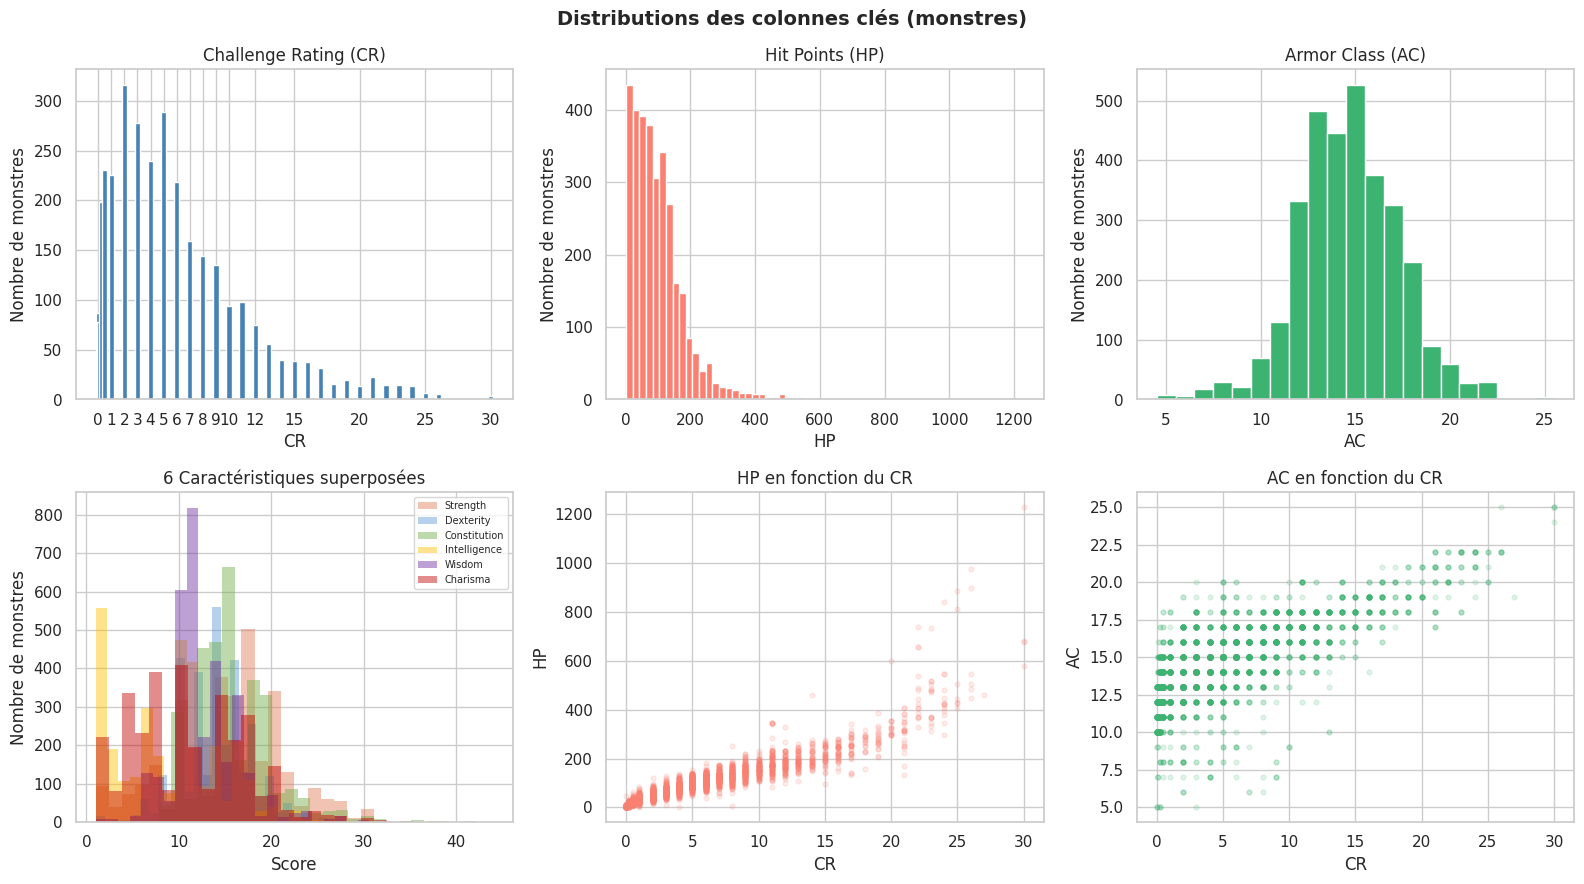

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Distributions des colonnes clés (monstres)", fontsize=14, fontweight="bold")

# CR — barplot car valeurs discrètes connues
cr_order = sorted(monsters["cr"].dropna().unique())
cr_counts = monsters["cr"].value_counts().reindex(cr_order, fill_value=0)
axes[0, 0].bar(cr_order, cr_counts.values, width=0.4, color="steelblue", edgecolor="white")
axes[0, 0].set_title("Challenge Rating (CR)")
axes[0, 0].set_xlabel("CR")
axes[0, 0].set_ylabel("Nombre de monstres")
axes[0, 0].set_xticks([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 20, 25, 30])

# HP
axes[0, 1].hist(monsters["hit_points"], bins=60, color="salmon", edgecolor="white")
axes[0, 1].set_title("Hit Points (HP)")
axes[0, 1].set_xlabel("HP")
axes[0, 1].set_ylabel("Nombre de monstres")

# AC
axes[0, 2].hist(monsters["armor_class"], bins=range(5, 27), color="mediumseagreen",
                edgecolor="white", align="left")
axes[0, 2].set_title("Armor Class (AC)")
axes[0, 2].set_xlabel("AC")
axes[0, 2].set_ylabel("Nombre de monstres")

# 6 ability scores superposés
stats = ["strength", "dexterity", "constitution", "intelligence", "wisdom", "charisma"]
colors = ["#e07b54", "#5b9bd5", "#70ad47", "#ffc000", "#7030a0", "#c00000"]
for stat, color in zip(stats, colors):
    axes[1, 0].hist(monsters[stat], bins=30, alpha=0.45, label=stat.capitalize(),
                    color=color, edgecolor="none")
axes[1, 0].set_title("6 Caractéristiques superposées")
axes[1, 0].set_xlabel("Score")
axes[1, 0].set_ylabel("Nombre de monstres")
axes[1, 0].legend(fontsize=7)

# HP vs CR (scatter)
axes[1, 1].scatter(monsters["cr"], monsters["hit_points"], alpha=0.15, s=12, color="salmon")
axes[1, 1].set_title("HP en fonction du CR")
axes[1, 1].set_xlabel("CR")
axes[1, 1].set_ylabel("HP")

# AC vs CR (scatter)
axes[1, 2].scatter(monsters["cr"], monsters["armor_class"], alpha=0.15, s=12,
                   color="mediumseagreen")
axes[1, 2].set_title("AC en fonction du CR")
axes[1, 2].set_xlabel("CR")
axes[1, 2].set_ylabel("AC")

plt.tight_layout()
plt.savefig(Path.cwd().parent / "results" / "monsters_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

### Lecture des graphiques

**CR (haut gauche)** — Distribution très déséquilibrée. Les CR 2–6 dominent largement, puis ça chute rapidement. Les grands CR (20+) sont rares.
> **Implication ML** : si on construit notre jeu d'entraînement directement depuis ces monstres, on aura un biais vers les combats faciles/moyens. Il faudra en tenir compte (stratification, sur-/sous-échantillonnage).

**HP (haut centre)** — Fortement asymétrique à droite (*right-skewed*). La majorité des monstres ont < 200 HP, mais quelques-uns montent jusqu'à 1230 (le Tarrasque...).
> **Implication** : une transformation `log1p(HP)` sera probablement utile à la Phase 3 pour ne pas écraser les petites valeurs.

**AC (haut droite)** — Distribution quasi-normale, centrée autour de 13–16. Bien plus propre que HP. La plage est raisonnable, aucune transformation nécessaire.

**6 caractéristiques (bas gauche)** — Toutes centrées autour de 10–16.
- La **Force** tire vers les hautes valeurs (monstres physiques).
- L'**Intelligence** est la plus basse et la plus dispersée.
- La **Charisme** a deux bosses : monstres bestials (faible CHA) et monstres magiques/sociaux (haut CHA).

**HP vs CR (bas centre)** — HP monte clairement avec CR, mais avec **beaucoup de variance** : un même CR peut avoir des HP très différents selon la source et le design du monstre. CR seul ne suffit pas à prédire HP.

**AC vs CR (bas droite)** — AC monte aussi avec CR mais **se plafonne autour de 20**. Aucun monstre ne dépasse AC 25, même au CR 30. L'AC seul ne suffit pas à capturer la difficulté d'un monstre de haut CR.

## 5. Corrélations entre features — Monstres

Une heatmap de corrélation (Pearson) sur les colonnes numériques utiles pour le ML.
Elle répond à une question clé : **quelles features sont liées entre elles, et lesquelles sont liées au CR ?**

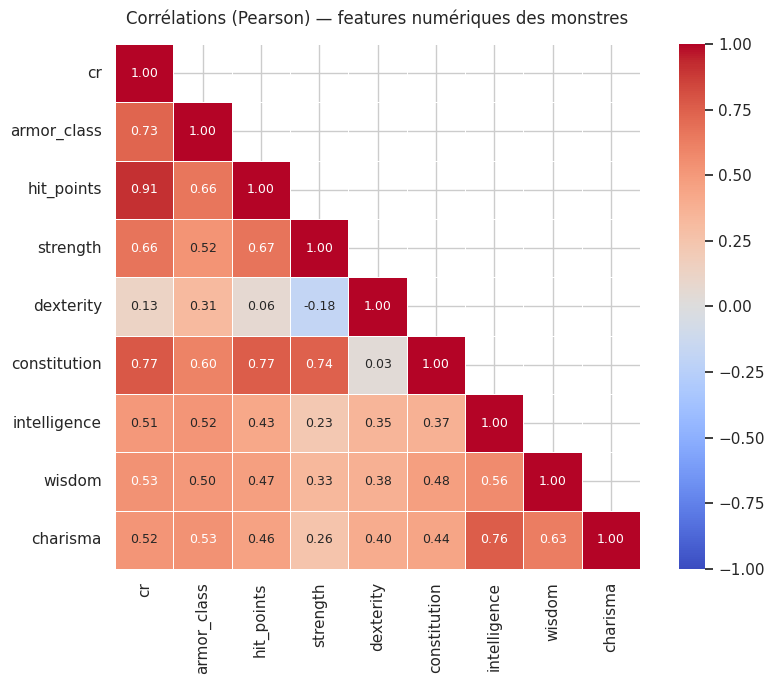

In [9]:
FEATURES = [
    "cr", "armor_class", "hit_points",
    "strength", "dexterity", "constitution",
    "intelligence", "wisdom", "charisma",
]

corr = monsters[FEATURES].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # masque le triangle supérieur
sns.heatmap(
    corr,
    mask=mask,
    annot=True, fmt=".2f", annot_kws={"size": 9},
    cmap="coolwarm", center=0, vmin=-1, vmax=1,
    linewidths=0.5, square=True, ax=ax,
)
ax.set_title("Corrélations (Pearson) — features numériques des monstres", fontsize=12, pad=14)
plt.tight_layout()
plt.savefig(Path.cwd().parent / "results" / "monsters_correlations.png", dpi=150, bbox_inches="tight")
plt.show()

### Lecture de la heatmap

**Corrélations avec le CR** (première colonne — notre variable cible future) :

| Feature | Corrélation avec CR | Interprétation |
|---|---|---|
| `hit_points` | **0.91** | Très forte — HP est le meilleur prédicteur individuel du CR |
| `constitution` | **0.77** | Forte — CON détermine directement les HP max |
| `armor_class` | **0.73** | Forte — les monstres dangereux sont aussi plus durs à toucher |
| `strength` | **0.66** | Modérée — monstres puissants = CR élevé |
| `wisdom` | 0.53 | Modérée — monstres sages = souvent plus tactiques/dangereux |
| `charisma` | 0.52 | Modérée — CHA élevé = souvent créatures magiques ou leaders |
| `intelligence` | 0.51 | Modérée — même logique que CHA |
| `dexterity` | **0.13** | Faible — la dextérité ne discrimine pas le CR |

**Corrélations entre features (redondance)** :
- `intelligence` ↔ `charisma` = **0.76** : très corrélées — les créatures intelligentes sont aussi charismatiques. En Phase 3, on pourra envisager de n'en garder qu'une, ou de les combiner.
- `constitution` ↔ `hit_points` = **0.77** : logique, CON détermine les HP.
- `strength` ↔ `constitution` = **0.74** : les créatures physiquement puissantes sont aussi robustes.
- `dexterity` ↔ `strength` = **-0.18** : légèrement négative — les créatures très fortes ont tendance à être moins agiles (ex. : grande brute vs. créature rapide).

**Ce qu'on retient pour la Phase 3 (feature engineering)** :
1. `hit_points` et `constitution` sont quasi-redondantes → `log1p(hit_points)` suffira probablement.
2. `dexterity` apporte une information indépendante (faible corrélation avec tout le reste) → à garder.
3. `intelligence` et `charisma` sont redondantes entre elles → possibilité de créer une feature composite `mental_score = (INT + WIS + CHA) / 3`.